In [943]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd
import sympy as sy
from sympy import sin, exp, cos
from IPython.display import display

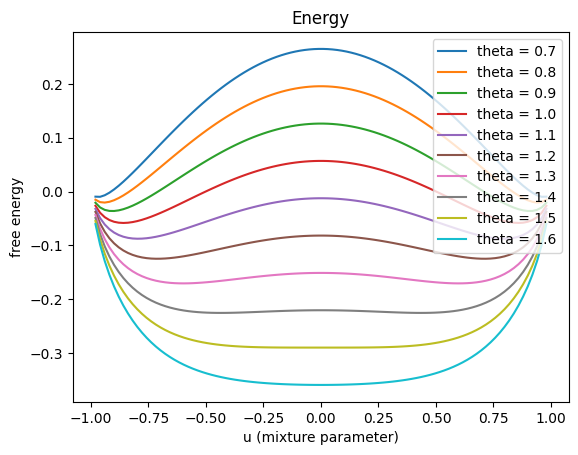

In [944]:
#logartihmic potential
temperatur_thetas = np.arange(0.7,1.7,0.1)
u = np.linspace(-1,1,100)
critical_temperature = 1.5

def log_potential(u,theta):
    l1 = (critical_temperature/2)*(1-u**2)
    l2 = (theta/2)*((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
    return l1 + l2

for theta in temperatur_thetas:
    y_vals = log_potential(u,theta)
    plt.plot(u,y_vals, label = f'theta = {np.round(theta,2)}')
    plt.legend()

plt.title("Energy")
plt.xlabel("u (mixture parameter)")
plt.ylabel("free energy")
plt.show()

In [945]:

def biharmonic_solver(Lx,Ly,Nx,Ny, F, c, mean):
    F_hat = fft2(F)
    kx = fftfreq(Nx, d=Lx/Nx) * 2 * np.pi
    ky = fftfreq(Ny, d=Ly/Ny) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2+KY**2
    KfourierSpace = (K2**2 + c)
    KfourierSpace[0,0] = 1

    u_hat = F_hat/KfourierSpace
    u_hat[0,0] = mean

    U = ifft2(u_hat).real

    return U

In [946]:
#parameters:
Nx1 = np.array([4,8,15,16,20,32])
Ny1 = 2*Nx1

k = np.arange(0,10)
Nx2 = 4+4*k
Ny2 =2*Nx2


In [947]:
#manufacture solutions: 
def manufacture_solution_biharmonic(u_string, c):
    x, y = sy.symbols('x y')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    f_symbolic = biharmonic + c*u_symbolic
    f_symbolic = sy.simplify(f_symbolic)

    u = sy.lambdify((x, y), u_symbolic, modules='numpy')
    f = sy.lambdify((x, y), f_symbolic, modules='numpy')

    return u,f


In [948]:
u1_string = 'sin(8*(x-1))*cos(4*y)'
u1,f1 = manufacture_solution_biharmonic(u1_string, c = 1)

u2_string = 'exp(sin(x)**2+cos(2*y))'
u2,f2 = manufacture_solution_biharmonic(u2_string, c = 0)

In [949]:

def compute_errors(f,NX,NY,u,c):
    errors = []
    eocs = []
    for i in range(len(NX)):
        Lx = 2*np.pi
        Ly = 4*np.pi
        Nx = NX[i]
        Ny = NY[i]
        x = np.linspace(0,Lx,Nx, endpoint=False)
        y = np.linspace(0,Ly,Ny, endpoint=False)
        X,Y = np.meshgrid(x,y, indexing="ij")

        F = f(X,Y)
        U_ex = u(X,Y)
        U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c, mean = 0)
        U += np.mean(U_ex)
        U_err = U - U_ex
        error = np.linalg.norm(U_err, np.inf)

        #append stuff
        errors.append(error)

        #convergences
        if len(errors) > 1:
            h_now = Lx / NX[i]
            h_prev = Lx / NX[i-1]
            eoc = np.log(errors[-1] / errors[-2]) / np.log(h_now / h_prev)
            eocs.append(eoc)
        else:
            eocs.append("Not yet...")

    return errors,eocs
        
errors1, eocs1 = compute_errors(f1,Nx1,Ny1,u1,c=1)
errors2, eocs2 = compute_errors(f2,Nx2,Ny2,u2,c=0)

In [950]:
df1 = pd.DataFrame({
    'Nx': Nx1,
    'Ny': Ny1,
    'Error': errors1,
    'EOC': eocs1
})

df2 = pd.DataFrame({
    'Nx': Nx2,
    'Ny': Ny2,
    'Error': errors2,
    'EOC': eocs2
})


display(df1), display(df2)

,Nx,Ny,Error,EOC
0,4,8,1.818989e-12,Not yet...
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


,Nx,Ny,Error,EOC
0,4,8,9.573099e+01,Not yet...
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775


(None, None)

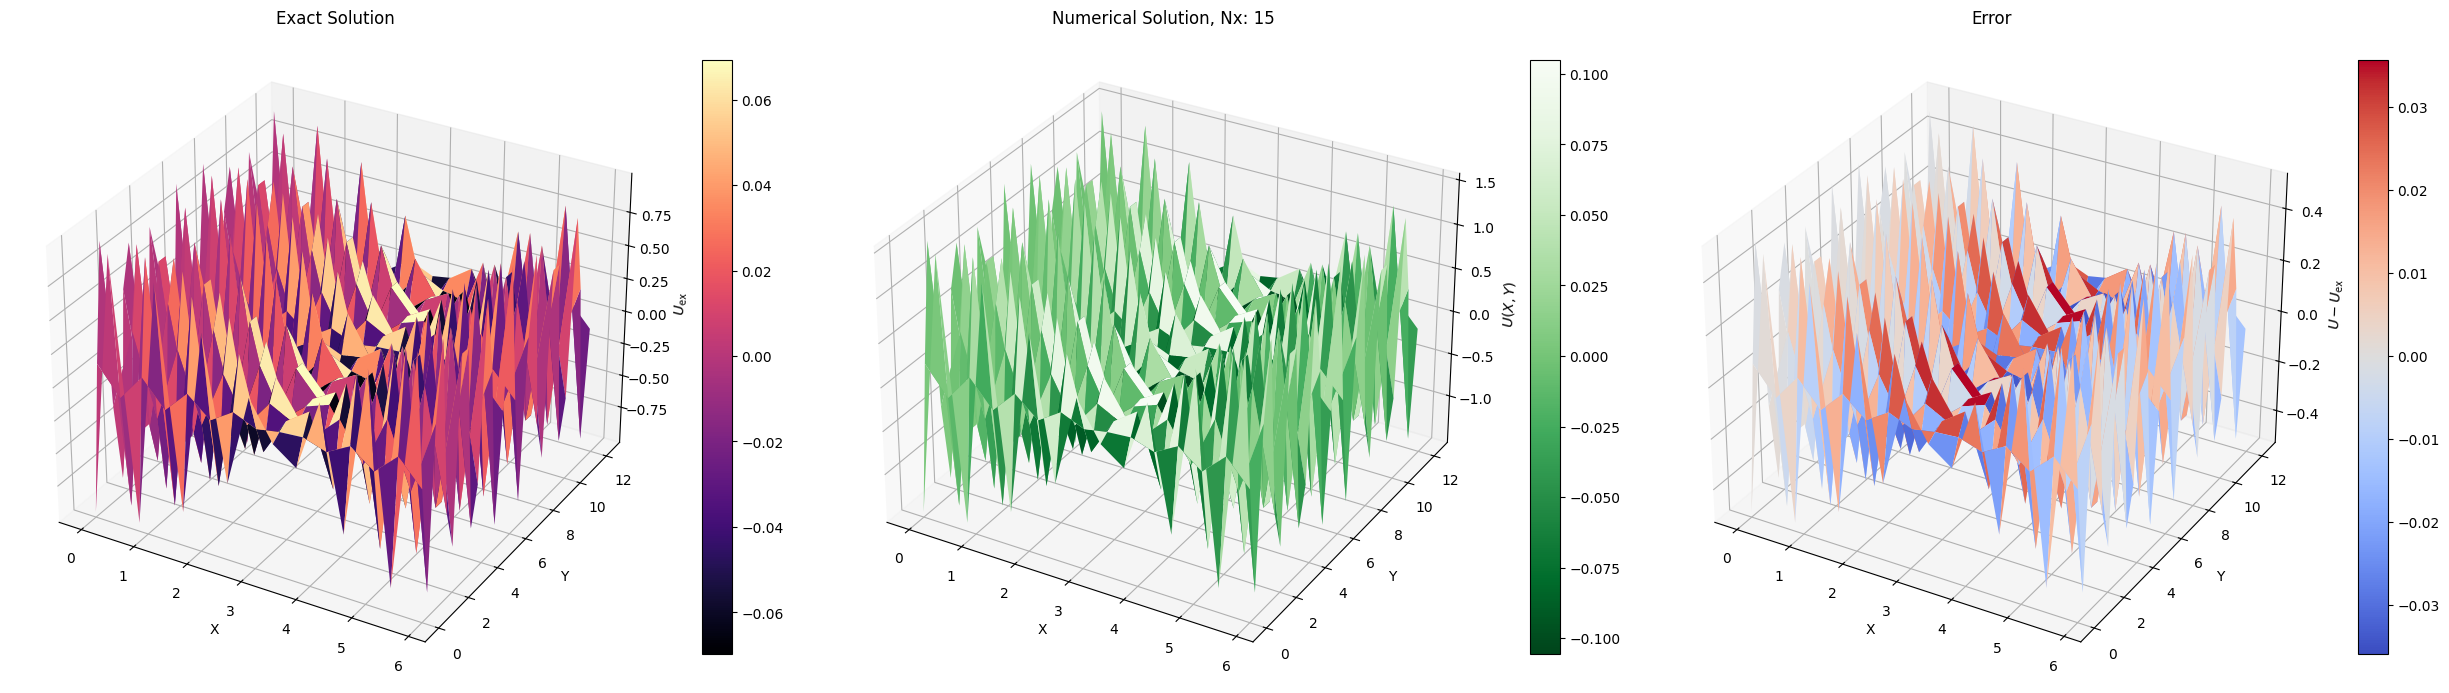

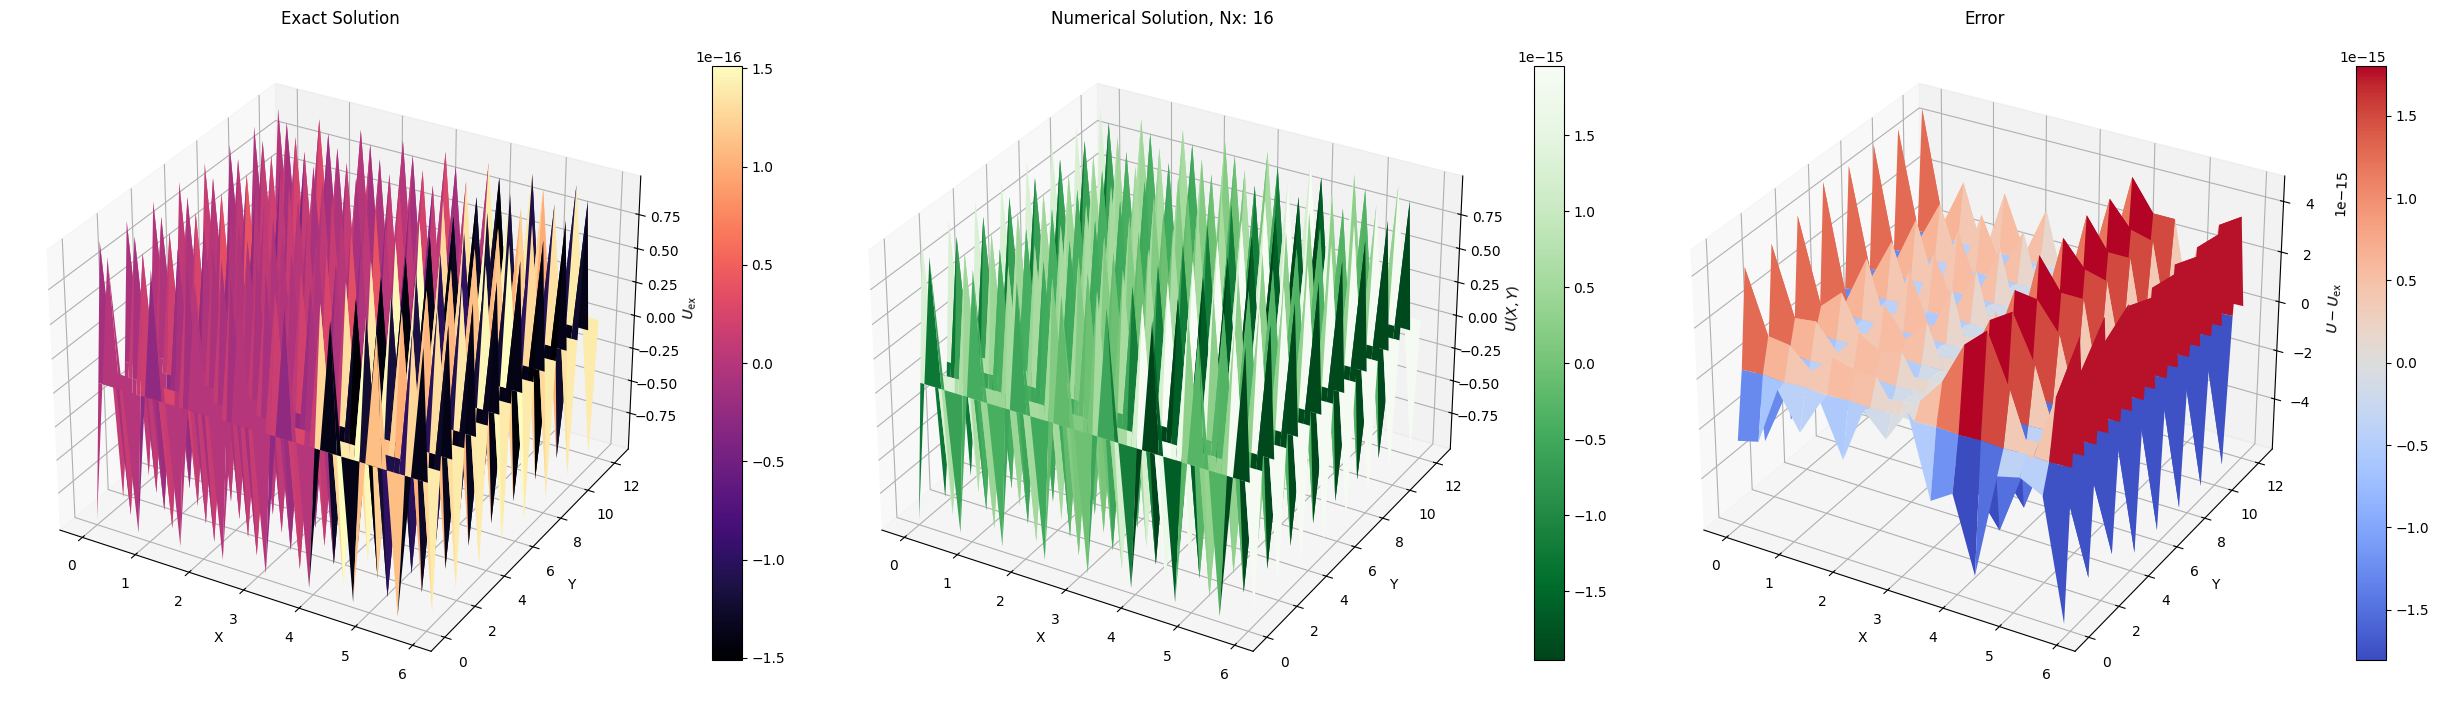

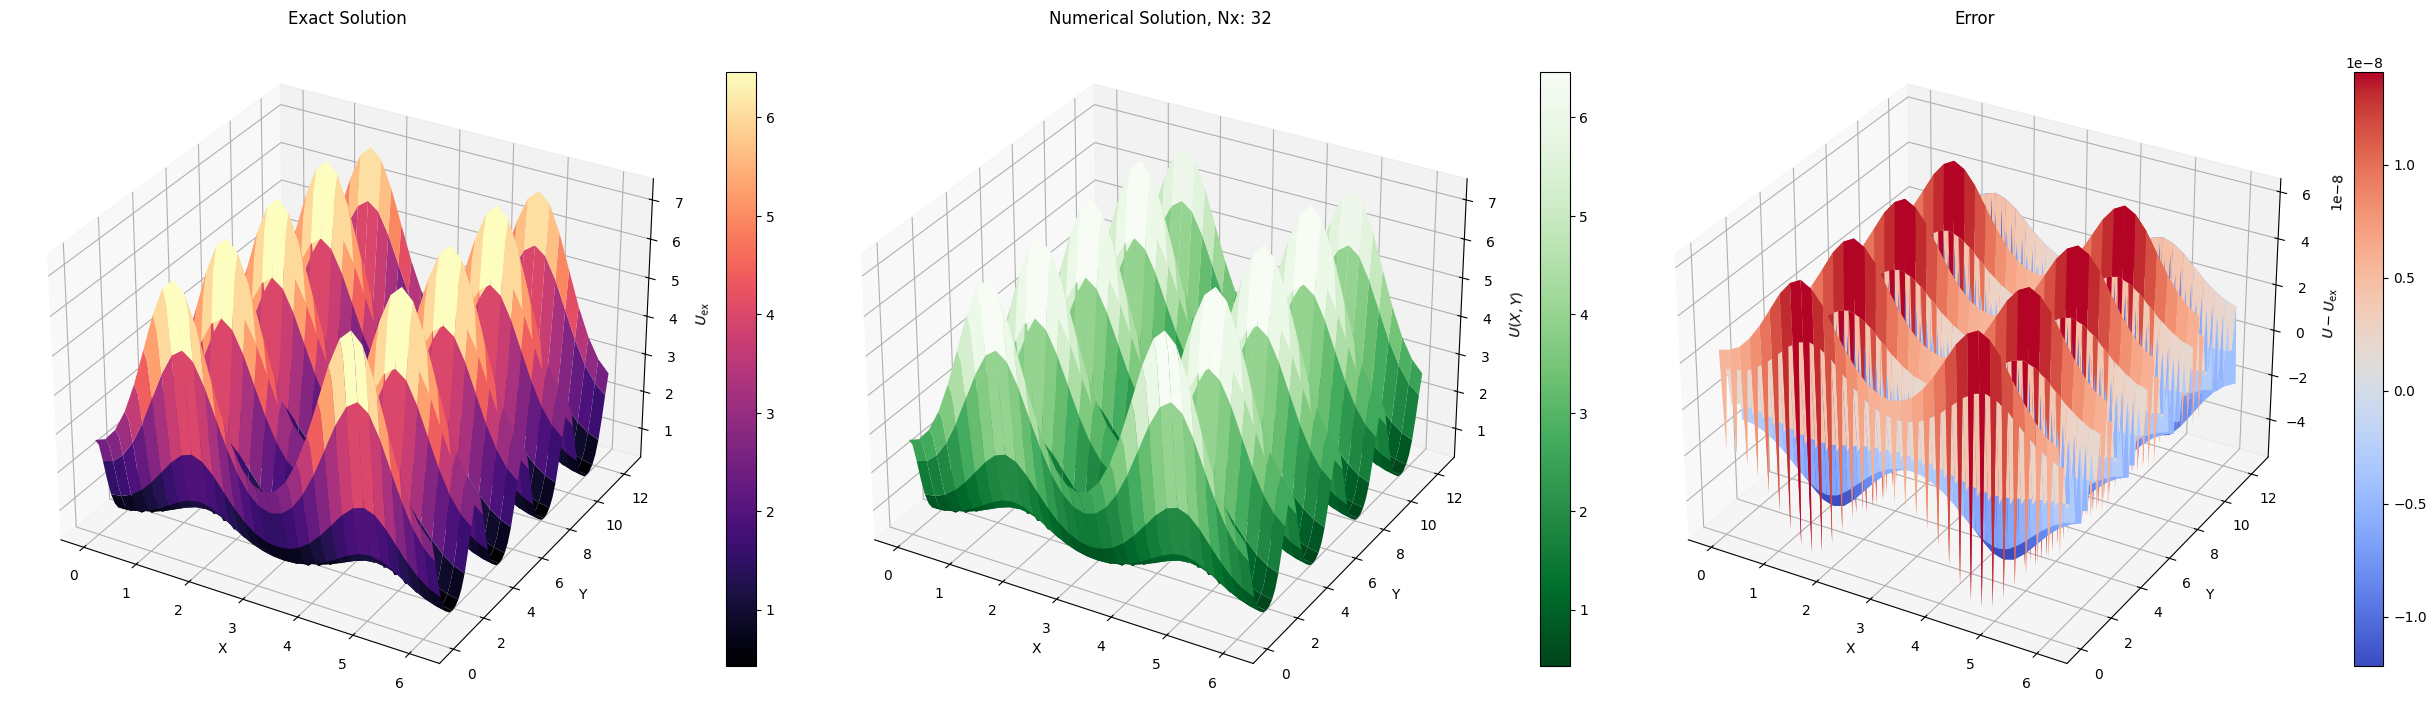

In [951]:
#surface plot:

def surface_plot(Nx,Lx,Ly,f,u,c_in):
    Ny = 2*Nx
    x = np.linspace(0,Lx,Nx, endpoint=False)
    y = np.linspace(0,Ly,Ny, endpoint=False)
    X,Y = np.meshgrid(x,y, indexing="ij")

    F = f(X,Y)
    U_ex = u(X,Y)
    U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c=c_in, mean = 0)
    U += np.mean(U_ex)
    U_err = U - U_ex

    fig = plt.figure(figsize=(25, 30))
    ax = fig.add_subplot(131, projection='3d')
    surf1 = ax.plot_surface(X, Y, U_ex, cmap='magma')
    fig.colorbar(surf1, shrink=0.2)
    ax.set_title("Exact Solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U_\mathrm{ex}$')

    ax = fig.add_subplot(132, projection='3d')
    surf2 = ax.plot_surface(X, Y,  U, cmap='Greens_r')
    fig.colorbar(surf2, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title(f'Numerical Solution, Nx: {Nx}')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U(X, Y)$')

    ax = fig.add_subplot(133, projection='3d')
    surf3 = ax.plot_surface(X, Y,  U_err, cmap='coolwarm')
    fig.colorbar(surf3, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title("Error")
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')
    plt.tight_layout()
    plt.show()

   


surface_plot(15,2*np.pi,4*np.pi,f1,u1,1)
surface_plot(16,2*np.pi,4*np.pi,f1,u1,1)
surface_plot(32,2*np.pi,4*np.pi,f2,u2,0)


### Task 3

Vi begynner med $\theta$  - metoden; den er definert slik:

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right), \quad \text{for } n = 0, 1, 2, \dots, N - 1
$

Herifra kan vi definere $k_1$ og $k_2$:

$k_1 = F(t_n, U^n)$  
$k_2 = F(t_{n+1}, U^{n+1}) = F(t_n + \tau, U^n + \tau(\theta k_2 + (1-\theta)k_1))$ 


*Nå kan vi skrive $\theta$  - metoden slik ved å benytte $k_1$ og $k_2$:*

$U^{n+1} = U^n + \tau \cdot (\theta k_2 + (1-\theta)k_1)$    

Fra dette kan vi utlede en generell butcher tabell ved å benytte at:

$$
k_j := f\left(t_k + c_j \tau,\ y_k + \tau \sum_{l=1}^{s} a_{jl} k_l\right), \quad j = 1, \dots, s,
$$  
  
$$
y_{k+1} := y_k + \tau \sum_{j=1}^{s} b_j k_j
$$

Butcher tabellen blir da i det generelle tilfellet slik:

$$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 - \theta & \theta \\
\hline
  & 1 - \theta & \theta
\end{array}
$$

  

Fra dette observerer vi noen kjente Runge-Kutta metoder:

**Forward Euler** ( $\theta = 0$)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 & 0 \\
\hline
  & 1 & 0
\end{array}
$

**Backward Euler** ($ \theta = 1 $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 0 & 1 \\
\hline
  & 0 & 1
\end{array}
$

**Crank–Nicolson** ($ \theta = \frac{1}{2} $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & \frac{1}{2} & \frac{1}{2} \\
\hline
  & \frac{1}{2} & \frac{1}{2}
\end{array}
$


**Konsistensorden for ulike $\theta$**   
*for å bestemme konsistensorden avhengig av theta benytter vi tabellen i forelesningsnotatene.*  
### Butcher-order conditions

| $p$ | Conditions |
|-----|------------|
| 1   | $\sum_{i=1}^{s} b_i = 1$ |
| 2   | $\sum_{i=1}^{s} b_i c_i = \frac{1}{2}$ |
| 3   | $\sum_{i=1}^{s} b_i c_i^2 = \frac{1}{3}$  <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j = \frac{1}{6}$ |
| 4   | $\sum_{i=1}^{s} b_i c_i^3 = \frac{1}{4}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i c_i a_{ij} c_j = \frac{1}{8}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j^2 = \frac{1}{12}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} \sum_{k=1}^{s} b_i a_{ij} a_{jk} c_k = \frac{1}{24}$ |   

Det første vi kan legge merke til er at uavhengig av theta vil alle metodene ha minst konsistensorden 1.  
Dette er fordi summen av $\sum_{i=1}^{2} b_i = 1 - \theta + \theta = 1$


  








In [952]:
theta = np.linspace(0,1,1000)
print("sjekk for noen theta verdier for konsistensorden:")
print("-------------------------------------")
for i in range(len(theta)):
    c1 = 0
    c2 = 1
    a11 = 0
    a12 = 0
    b1 = 1 - theta[i]
    b2 = theta[i]
    a21 = 1- theta[i]
    a22 = theta[i]
    #check for p = 2:
    sum = b1*c1+b2*c2
    if sum < 0.5005 and sum > 0.499:
        print("check for p = 2:")
        print("p = 2: ", np.round(theta[i],2))
        print("theta = 0.5 er dermed en theta verdi som gir konsistensorden 2!")

    #check for p = 3:

    sum1 = b1*c1**2+b2*c2**2
    if sum < 0.33334 and sum > 0.333:
        print("check for p = 3:")
        sum2 = b2*c2*a21 + b2*c2*a22
        print(sum2, " != ", 1/6)
        print("---------------------------------------")

sjekk for noen theta verdier for konsistensorden:
-------------------------------------
check for p = 3:
0.33333333333333337  !=  0.16666666666666666
---------------------------------------
check for p = 2:
p = 2:  0.5
theta = 0.5 er dermed en theta verdi som gir konsistensorden 2!


## kommentar til koden:

Kodesnutten itererer gjennom noen theta verdier og tester for konsistensorden 2 og 3.  
Ved konsistensorden 2 er det kun en verdi av theta som gir denne konsistensordenen. Nemlig $\theta = \frac{1}{2}$, altså Crank-Nicholson metoden! for konsistensorden 3 finnes at når theta 1/3 men dette stemmer ikke med den andre betingelsen, da kan vi si at ingen theta gir konsistensorden større enn 2.

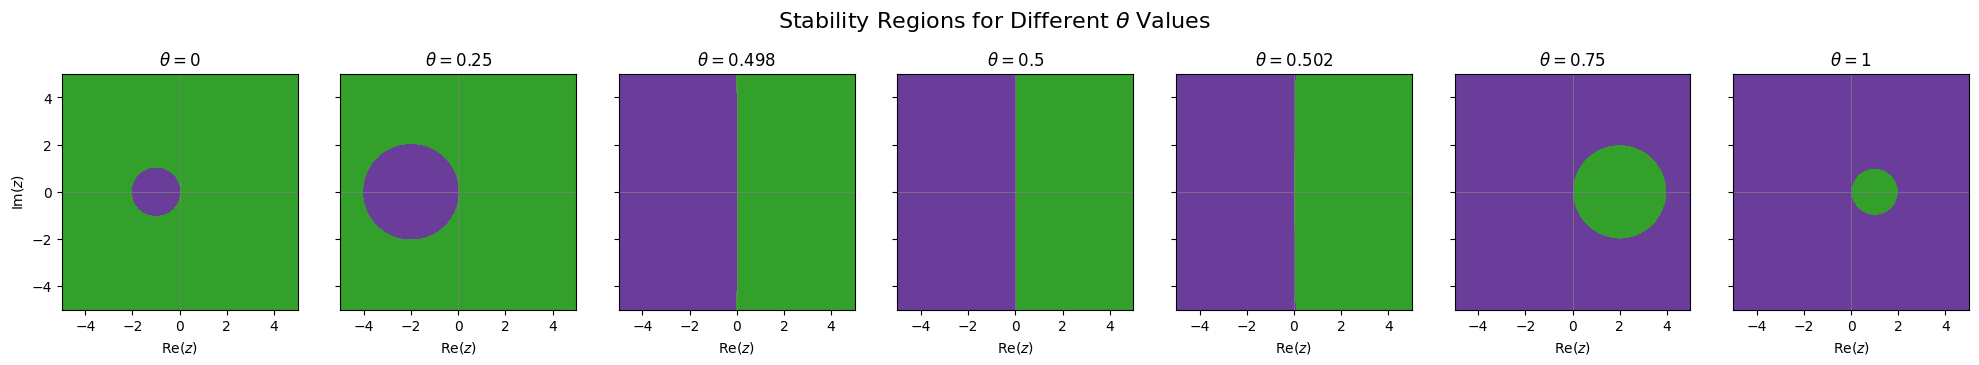

In [958]:

a = np.linspace(-5, 5, 1000)
b = np.linspace(-5, 5, 1000)
A, B = np.meshgrid(a, b)
Z = A + B * 1j

# Stabilitetsfunksjonen
def Rz(Z, theta):
    R = 1 + Z / (1 - Z * theta)
    return np.abs(R)

fig, axes = plt.subplots(1, 7, figsize=(20, 5), sharex=True, sharey=True)

# Theta-verdier
theta_vals = [0, 0.25, 0.498, 0.5, 0.502,0.75,1]

# Plot hver region på sin egen aksis
for ax, theta in zip(axes, theta_vals):
    ax.contourf(A, B, Rz(Z, theta) <= 1, cmap='Paired', levels=1)
    ax.set_title(rf"$\theta = {theta}$")
    ax.set_xlabel("Re$(z)$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect("equal")

axes[0].set_ylabel("Im$(z)$")
fig.suptitle("Stability Regions for Different $\\theta$ Values", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.show()


# Theoretical Task 3

Stabilitetsfunksjonen utledes fra definisjonen av $\theta$ - metoden

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$  

Og vi definerer:

$F(t_n, U^n) = \lambda \cdot U^n$  
$F(t_{n+1}, U^{n+1}) = \lambda \cdot U^{n+1} $

$U^{n+1} = U^n + \tau ((\theta \lambda \cdot U^{n+1})  + (1 - \theta) \lambda \cdot U^n ) $  

Vi gjør litt algebra her og definerer:

$Z = \lambda \tau$  

Deretter oppnår vi stabilitetsfunksjonen for metoden, som gir stabile områder der:
  
$r_{\theta}(Z) <= 1$

$r_{\theta}(Z) = \frac{U^{n+1}}{U^n} = 1 + \frac{Z}{1-Z \theta}$

Grensen for stabilitetsregionen er dermed gitt ved:  

$
\partial S_\theta = \left\{ z \in \mathbb{C} \;:\; |r_\theta(z)| = 1 \right\}
$

Fra dette kan vi prøve å forenkle uttrykket:
Vi starter med:   

$|r_\theta(z)| = |1 + \frac{Z}{1-Z \theta}|=  |\frac{1+Z(1-\theta)}{1-Z \theta}| = 1$

for komplekse brøker gjelder:

$|\frac{a}{b}| = \frac{|a|}{|b|}$

$|\frac{1+Z(1-\theta)}{1-Z \theta} = |1 \iff 1+Z(1-\theta)| = |1-Z \theta|$  

Kvadrerer begge sidene:  

$|1+Z(1-\theta)|^2 = |1-Z \theta|^2$ 

Nå kan vi sette inn $x$ og $iy$ for z og oppnår:  

$|1+(x+iy)(1-\theta)|^2 = |1-(x+iy) \theta|^2$ 

samtidig benytter vi at for et komplekst tall at:

$|w|^2 = x^2 + y^2$  

Da kan vi skrive om likninga over til:  

$[1+x(1-\theta)]^2 + [y(1-\theta)]^2 = [1-x \theta]^2+[y \theta]^2$

nå kan vi utvide og forenkle uttrykk:

$(1 + 2x(1 - \theta) + x^2(1- \theta)^2) + y^2(1- \theta)^2 = (1 - 2x \theta + x^2 \theta^2) + y^2 \theta^2$

vi oppnår da:

$2x + (1 - 2\theta)(x^2+y^2) = 0$

Dette likner på likningen for en sirkel og vi innfører en ny variabel $\beta$ for å forenkle og fullfører kvadratet:  

$\beta = 1 - 2\theta$

$\frac{2x}{\beta} + x^2 + y^2 = 0$

Vi får sirkellikninga:  

$(x+\frac{1}{\sqrt{\beta}})^2 + y^2 = \frac{1}{\beta}$

Vi kan gjøre noen generelle observasjoner her:












